# Práctica - Ensambles (Bagging/Boosting)

Veremos la comparativa en aplicar distintos métodos vistos en la teórica:

- Árbol de decisión individual

- Bagging
  - Random Forest

- Boosting
  - Adaboost

In [1]:
# Paquetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# ML
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [2]:
# Descarga de dataset de Titanic
!gdown 17mMxQC98Ni-NhBBLkP4d2sSiYt2OdfwD

# Target: "Survived"
# Features a utilizar: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked

Downloading...
From: https://drive.google.com/uc?id=17mMxQC98Ni-NhBBLkP4d2sSiYt2OdfwD
To: /content/Titanic-Dataset.csv
100% 61.2k/61.2k [00:00<00:00, 18.6MB/s]


In [3]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    int64  
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Fare      712 non-null    float64
 7   Embarked  712 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 50.1 KB


In [4]:
# Seleccionar columnas relevantes
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# Eliminar filas con valores nulos
df = df.dropna()

# Codificar variables categóricas
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Separar features y target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Dividir en train y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape, X_test.shape)

(498, 7) (214, 7)


## Árbol individual

Planteemos un árbol individual sin límites en la profundidad. Se espera que aprenda muy bien los datos de entrenamiento pero que no pueda generalizar correctamente (alta varianza, bajo desempeño en test)

In [27]:

# Crear el modelo
arbol = DecisionTreeClassifier(random_state=42)

# Entrenar
arbol.fit(X_train, y_train)

# Predicciones
y_train_pred = arbol.predict(X_train)
y_test_pred = arbol.predict(X_test)

# Métricas
print("Accuracy en entrenamiento:", accuracy_score(y_train, y_train_pred))
print("Accuracy en test:", accuracy_score(y_test, y_test_pred))

print("Matriz de confusión en test:")
print(confusion_matrix(y_train, y_train_pred))


Accuracy en entrenamiento: 0.9939759036144579
Accuracy en test: 0.6962616822429907
Matriz de confusión en test:
[[302   0]
 [  3 193]]


### ¿Qué efecto tiene la semilla cuando se arma el árbol?

In [6]:
#Generamos vector de semillas
semillas = np.random.randint(89000,size=1000)
train = []
test = []
for semilla in semillas:
  arbol = DecisionTreeClassifier(random_state=semilla)
  arbol.fit(X_train, y_train)
  y_train_pred = arbol.predict(X_train)
  y_test_pred = arbol.predict(X_test)
  train.append(accuracy_score(y_train, y_train_pred))
  test.append(accuracy_score(y_test, y_test_pred))



In [7]:
print(f'ACC min en test:{min(test)}')
print(f'ACC max en test:{max(test)}')
print(f'Media ACC en test:{sum(test)/len(test)}') #Media

ACC min en test:0.6962616822429907
ACC max en test:0.7336448598130841
Media ACC en test:0.7120233644859814


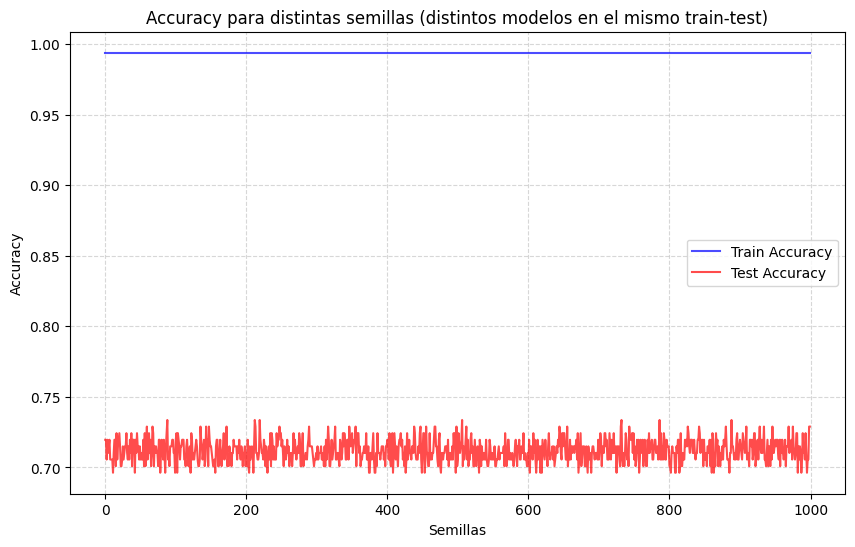

In [8]:
# Creamos figura
plt.figure(figsize=(10, 6))

# Ploteo las métricas de entrenamiento y test
plt.plot(train, label='Train Accuracy', color='blue', alpha=0.7)
plt.plot(test, label='Test Accuracy', color='red', alpha=0.7)

# Agregamos labels
plt.xlabel('Semillas')
plt.ylabel('Accuracy')
plt.title('Accuracy para distintas semillas (distintos modelos en el mismo train-test)')
plt.legend()

# Grafico
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Algunas cuestiones a ver en este gráfico:

- Un solo árbol de decisión es inestable: su desempeño depende mucho de la semilla.

- Árboles sobreajustan al conjunto de entrenamiento (test varía más que train).

¿ Por qué varía test?

La única fuente de aleatoriedad es cómo el árbol:

- Decide qué feature/variable/atributo cortar primero.

- Desempata entre múltiples opciones equivalentes.


## ¿Y si armamos distintos modelos en cada caso con un distinto sampleo (Bootstrap)?

Armemos árboles con una muestra aleatoria diferente de X_train. Usaremos el resample

Lo que ve cada modelo es distinto en cada iteración.

In [9]:
bootstrap_train_acc = []
bootstrap_test_acc = []

for _ in range(1000):
    # Bootstrap sample del set de entrenamiento. Esto quiere decir tomar la misma cantidad de registros pero de forma aleatoria
    # Hay registros que pueden desaparecer, otros que pueden aparecer más veces, etc

    #En este caso hacemos con la muestra de sampleo del mismo tamaño que X_train, pudiendo elegir multiples filas
    X_sample, y_sample = resample(X_train, y_train, replace=True)

    arbol = DecisionTreeClassifier()
    arbol.fit(X_sample, y_sample)

    # Evaluación sobre los datos reales
    # Hago predicción sobre train con el modelo entrenado del resample
    y_train_pred = arbol.predict(X_train)
    y_test_pred = arbol.predict(X_test)

    bootstrap_train_acc.append(accuracy_score(y_train, y_train_pred))
    bootstrap_test_acc.append(accuracy_score(y_test, y_test_pred))

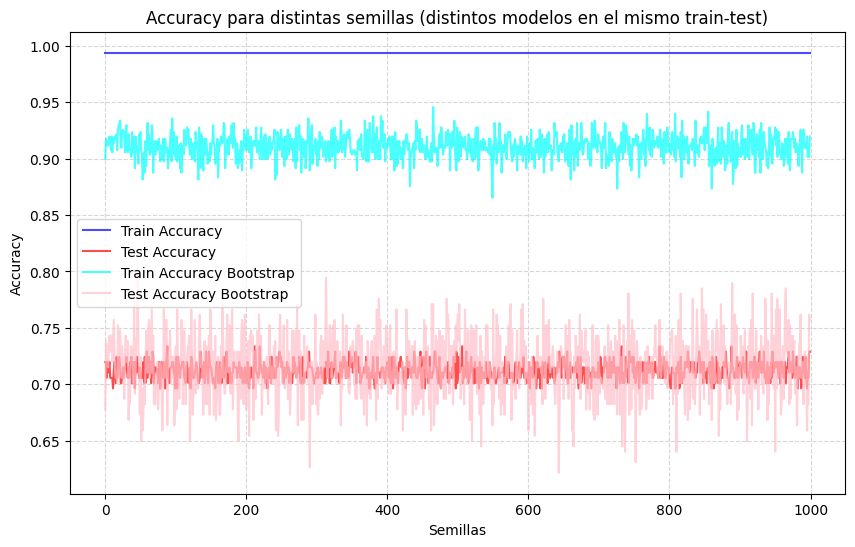

In [10]:
# Creamos figura
plt.figure(figsize=(10, 6))

# Ploteo las métricas de entrenamiento y test
plt.plot(train, label='Train Accuracy', color='blue', alpha=0.7)
plt.plot(test, label='Test Accuracy', color='red', alpha=0.7)

# Ploteo las métricas bootstrap
plt.plot(bootstrap_train_acc, label='Train Accuracy Bootstrap', color='cyan', alpha=0.7)
plt.plot(bootstrap_test_acc, label='Test Accuracy Bootstrap', color='pink', alpha=0.7)

# Agregamos labels
plt.xlabel('Semillas')
plt.ylabel('Accuracy')
plt.title('Accuracy para distintas semillas (distintos modelos en el mismo train-test)')
plt.legend()

# Grafico
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

¿ Qué diferencias hay en esto respecto a las 1000 semillas distintas?

- Cada árbol se entrena con una muestra aleatoria distinta de X_train. Lo que ve cada modelo es distinto en cada iteración (se resetea X_train y X_test)

- Los árboles ganan diversidad por el resample y sus fronteras se "suavizan".
Hay más diversidad en los árboles, con modelos que pueden ajustarse a diferentes “partes” del espacio de datos.

- El desempeño en train es variable y menor al anterior porque entrenamos con menos datos que los que tiene X_train. Algunos modelos pueden sobreajustar más (porque les toca un conjunto más pequeño o más repetido), otros menos.


***Bootstrap mejora la generalización***


A continuación está el ejemplo de aplicar el Bagging Classifier donde se hace el muestreo y luego se pondera de la cantidad de árboles creados (n_estimators como hiperparámetro) la clase final que se le asignará a la instancia a predecir.



In [11]:
# Creamos un bagging classifier.

# Creemos un modelo de bagging
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),  # Árbol como estimador base
    n_estimators=100,                         # Cantidad de árboles
    bootstrap=True,                           # Usar muestras bootstrap
    n_jobs=-1,
    random_state=42                           # Para reproducibilidad
)

# Entrenamiento del modelo
bagging_model.fit(X_train, y_train)

# Predicciones
y_train_pred = bagging_model.predict(X_train)
y_test_pred = bagging_model.predict(X_test)

# Evaluación
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

Train Accuracy: 0.9940
Test Accuracy:  0.7617


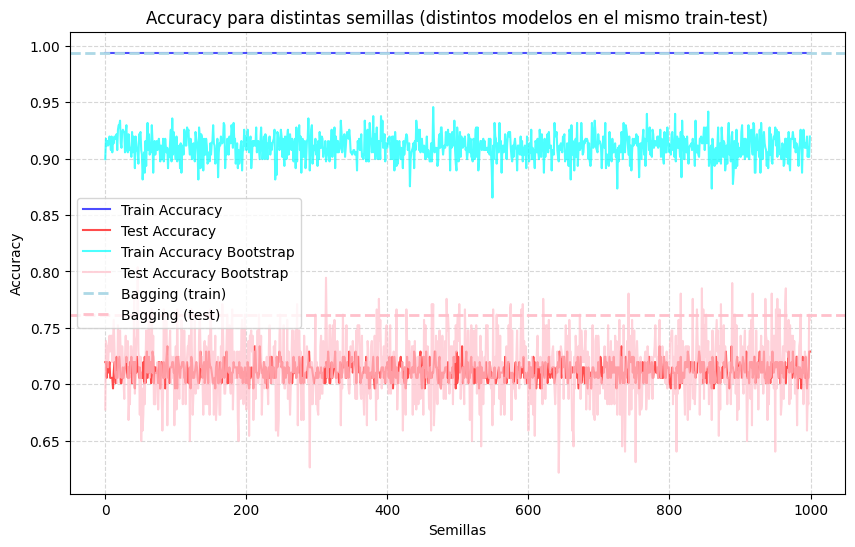

In [12]:
# Creamos figura
plt.figure(figsize=(10, 6))

# Ploteo las métricas de entrenamiento y test
plt.plot(train, label='Train Accuracy', color='blue', alpha=0.7)
plt.plot(test, label='Test Accuracy', color='red', alpha=0.7)

# Ploteo las métricas bootstrap
plt.plot(bootstrap_train_acc, label='Train Accuracy Bootstrap', color='cyan', alpha=0.7)
plt.plot(bootstrap_test_acc, label='Test Accuracy Bootstrap', color='pink', alpha=0.7)

# Ploteo métrica de Bagging
plt.axhline(train_acc, color='lightblue', linestyle='--', label='Bagging (train)', linewidth=2)
plt.axhline(test_acc, color='pink', linestyle='--', label='Bagging (test)', linewidth=2)


# Agregamos labels
plt.xlabel('Semillas')
plt.ylabel('Accuracy')
plt.title('Accuracy para distintas semillas (distintos modelos en el mismo train-test)')
plt.legend()

# Grafico
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Random Forest

Este modelo nos permitirá hacer:
- Bootstrap automático (el resample está dentro del método)
- Selección aleatoria de features (max_features) por cada árbol generado - $\sqrt{n}$ atributos
- Promedio de predicciones (votación) para definir la clase.



In [13]:
#Generamos un modelo random-forest de 100 árboles
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf.predict(X_test))



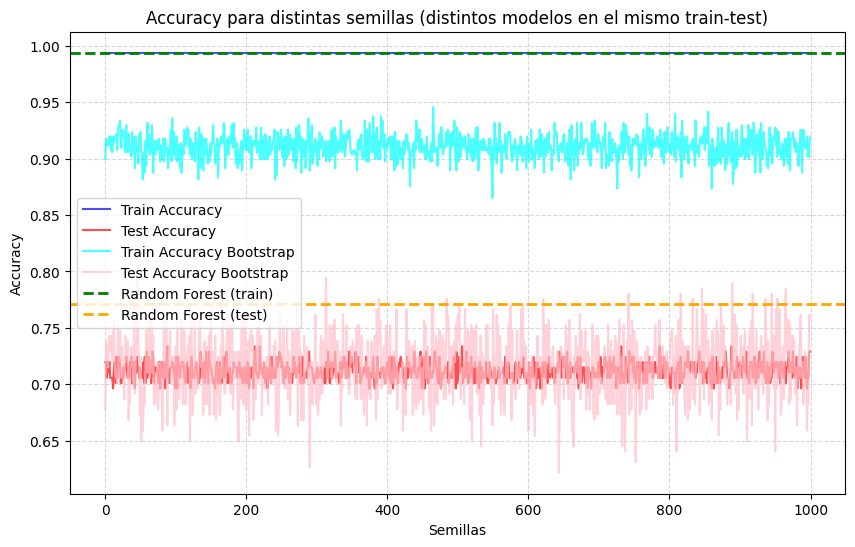

In [14]:
# Creamos figura
plt.figure(figsize=(10, 6))

# Ploteo las métricas de entrenamiento y test
plt.plot(train, label='Train Accuracy', color='blue', alpha=0.7)
plt.plot(test, label='Test Accuracy', color='red', alpha=0.7)

# Ploteo las métricas bootstrap
plt.plot(bootstrap_train_acc, label='Train Accuracy Bootstrap', color='cyan', alpha=0.7)
plt.plot(bootstrap_test_acc, label='Test Accuracy Bootstrap', color='pink', alpha=0.7)

# Ploteo métrica de random-forest
plt.axhline(rf_train_acc, color='green', linestyle='--', label='Random Forest (train)', linewidth=2)
plt.axhline(rf_test_acc, color='orange', linestyle='--', label='Random Forest (test)', linewidth=2)

# Agregamos labels
plt.xlabel('Semillas')
plt.ylabel('Accuracy')
plt.title('Accuracy para distintas semillas (distintos modelos en el mismo train-test)')
plt.legend()

# Grafico
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

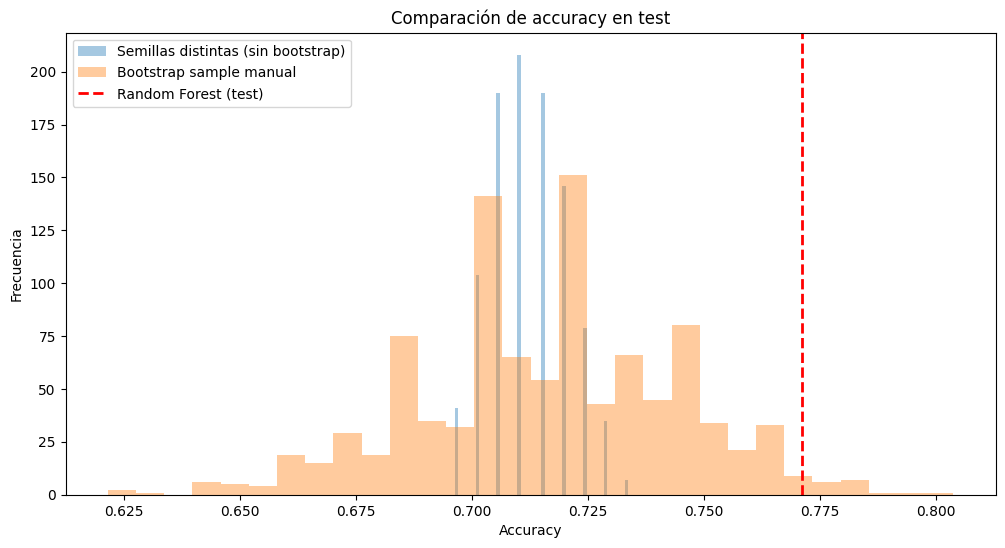

In [15]:
#Comparemos las metricas en test con distribuciones
plt.figure(figsize=(12, 6))

# Histogramas comparativos de accuracy en test
plt.hist(test, bins=50, alpha=0.4, label='Semillas distintas (sin bootstrap)')
plt.hist(bootstrap_test_acc, bins=30, alpha=0.4, label='Bootstrap sample manual')
plt.axvline(rf_test_acc, color='red', linestyle='--', label='Random Forest (test)', linewidth=2)

plt.title('Comparación de accuracy en test')
plt.xlabel('Accuracy')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

### ¿Y si fue un Random Forest que tiene la suerte de tener una buena performance por la semilla?

Probemos iterar RF en las 1000 semillas del comienzo


In [16]:
train_rf = []
test_rf = []
# Generemos un RF por cada semilla (paralelizar 100 arboles, 1000 veces)
for semilla in semillas:
  rf = RandomForestClassifier(n_estimators=100, random_state=semilla)
  rf.fit(X_train, y_train)
  rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
  rf_test_acc = accuracy_score(y_test, rf.predict(X_test))
  train_rf.append(rf_train_acc)
  test_rf.append(rf_test_acc)




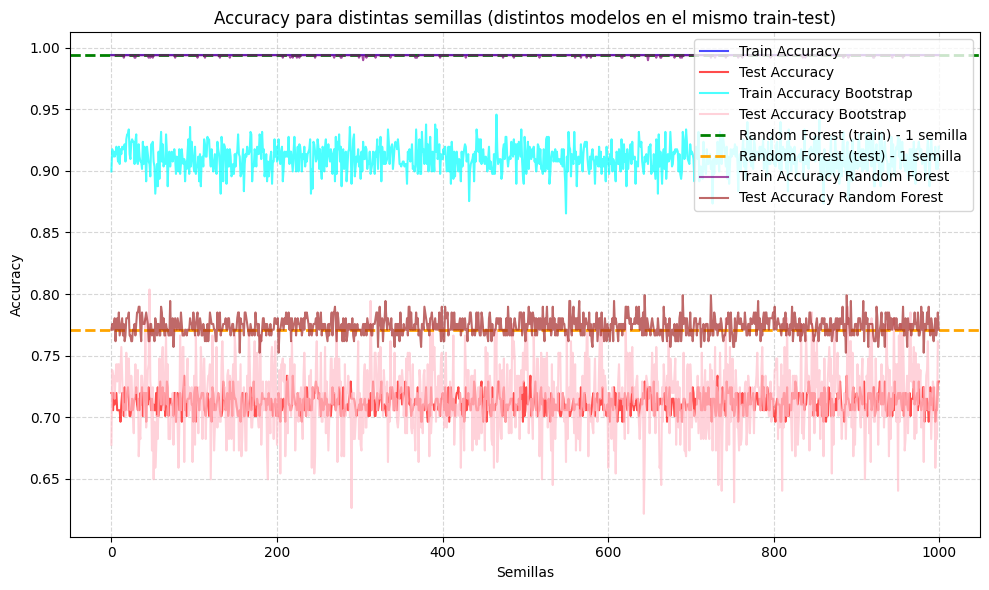

In [17]:
# Creamos figura
plt.figure(figsize=(10, 6))

# Ploteo las métricas de entrenamiento y test
plt.plot(train, label='Train Accuracy', color='blue', alpha=0.7)
plt.plot(test, label='Test Accuracy', color='red', alpha=0.7)

# Ploteo las métricas bootstrap
plt.plot(bootstrap_train_acc, label='Train Accuracy Bootstrap', color='cyan', alpha=0.7)
plt.plot(bootstrap_test_acc, label='Test Accuracy Bootstrap', color='pink', alpha=0.7)

# Ploteo métrica de random-forest
plt.axhline(rf_train_acc, color='green', linestyle='--', label='Random Forest (train) - 1 semilla', linewidth=2)
plt.axhline(rf_test_acc, color='orange', linestyle='--', label='Random Forest (test) - 1 semilla', linewidth=2)
plt.plot(train_rf, label='Train Accuracy Random Forest', color='purple', alpha=0.7)
plt.plot(test_rf, label='Test Accuracy Random Forest', color='brown', alpha=0.7)

# Agregamos labels
plt.xlabel('Semillas')
plt.ylabel('Accuracy')
plt.title('Accuracy para distintas semillas (distintos modelos en el mismo train-test)')
plt.legend(loc='upper right')
plt.tight_layout()

# Grafico
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

- En test, RF muestra mejor desempeño promedio y menor varianza que árboles individuales.

- El promedio de árboles ayuda a mitigar el sobreajuste individual (ver curvas en train de RF)

- **Más robustez y mejor generalización**

- Es importante recalcar como el uso de ensambles es indispensable para obtener un modelo competitivo en la competencia del TP2, ya que viendo el gráfico se observa que sobre nuestro X_test (una muestra de datos que ningún método aplicado en el Colab está viendo, asimilable a los datos de Kaggle que buscan predecir) la mejor performance viene dada en los 1000 casos (generalizando a "n") por un ensamble frente al modelo individual.

______________________________________

¿ Por qué Bagging tiene más varianza que un mismo árbol si debiera generalizar mejor?

Repasando el análisis,
- El modelo de árbol sencillo genera 1000 árboles que ven el mismo X_train siempre. Cambia nomás cómo resuelve situaciones entre features o donde deba desempatar (fenómeno aleatorio con random_state).
- El bagging (con bootstrap o reposición) que hicimos entrena 1000 arboles distintos que ven un X_train distinto. Esas instancias entrenan cada vez un modelo distinto cada vez. Son modelos bastante "distintos" que los primeros y puede confundir la visualización de los mismos en la misma gráfica buscándolos hacer comparables.

Por lo tanto,
- Bagging genera árboles individuales con mayor varianza que cambiando solo la semilla.
- **El modelo final (el promedio/votación de esos árboles) tiene menor varianza en su predicción total. Podemos pensarlo como tener estimadores ruidosos y promediarlos entre todos. Obtendremos algo estable y preciso. Este fenómeno se evidencia en la aplicación de Random Forest.**




### ¿Y este es el mejor modelo que podemos hallar?

No, aún faltará buscar optimizar los hiperparámetros que creamos necesarios! Vamos a probar con un Grid Search en algunos hiperparámetros.



In [18]:
# Definimos el espacio de búsqueda
param_grid = {
    'n_estimators': [50, 100,150 ,200], #Cantidad de árboles a paralelilzar
    'min_samples_split': [2, 5, 10,15], # Número mínimo de instancias para hacer un split
    'min_samples_leaf': [1, 2, 4,10], # Número mínimo de muestras requeridas en una hoja (nodo final del árbol)
    'max_features': ['sqrt', 'log2'], #cantidad de features a tomar por árbol
}

# Modelo base
rf = RandomForestClassifier(random_state=42)

# Búsqueda de hiperparámetros
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=1, verbose=3)

# Entrenamos
grid_search.fit(X_train, y_train)

# Mejor combinación
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor accuracy en cross-val:", grid_search.best_score_)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
[CV 1/5] END max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.710 total time=   0.1s
[CV 2/5] END max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.820 total time=   0.1s
[CV 3/5] END max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.780 total time=   0.1s
[CV 4/5] END max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.788 total time=   0.1s
[CV 5/5] END max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.859 total time=   0.1s
[CV 1/5] END max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.710 total time=   0.2s
[CV 2/5] END max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.810 total time=   0.2s
[CV 3/5] END max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estima

In [19]:
mejor_rf = grid_search.best_estimator_
best_rf_train_acc = mejor_rf.score(X_train, y_train)
best_rf_test_acc = mejor_rf.score(X_test, y_test)

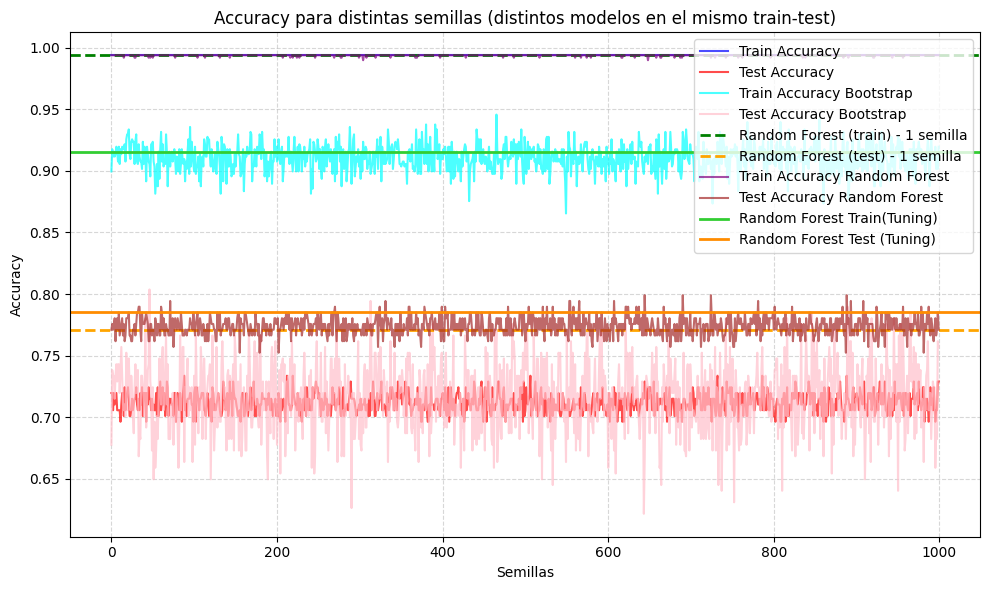

In [20]:
# Creamos figura
plt.figure(figsize=(10, 6))

# Ploteo las métricas de entrenamiento y test
plt.plot(train, label='Train Accuracy', color='blue', alpha=0.7)
plt.plot(test, label='Test Accuracy', color='red', alpha=0.7)

# Ploteo las métricas bootstrap
plt.plot(bootstrap_train_acc, label='Train Accuracy Bootstrap', color='cyan', alpha=0.7)
plt.plot(bootstrap_test_acc, label='Test Accuracy Bootstrap', color='pink', alpha=0.7)

# Ploteo métrica de random-forest
plt.axhline(rf_train_acc, color='green', linestyle='--', label='Random Forest (train) - 1 semilla', linewidth=2)
plt.axhline(rf_test_acc, color='orange', linestyle='--', label='Random Forest (test) - 1 semilla', linewidth=2)
plt.plot(train_rf, label='Train Accuracy Random Forest', color='purple', alpha=0.7)
plt.plot(test_rf, label='Test Accuracy Random Forest', color='brown', alpha=0.7)
# RF con búsqueda de hiperparámetros
plt.axhline(best_rf_train_acc, color='limegreen', linestyle='-', label='Random Forest Train(Tuning)', linewidth=2)
plt.axhline(best_rf_test_acc, color='darkorange', linestyle='-', label='Random Forest Test (Tuning)', linewidth=2)

# Agregamos labels
plt.xlabel('Semillas')
plt.ylabel('Accuracy')
plt.title('Accuracy para distintas semillas (distintos modelos en el mismo train-test)')
plt.legend(loc='upper right')
plt.tight_layout()

# Grafico
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Boosting

Utilizaremos como ejemplo AdaBoost dentro de un ensamble del tipo Boosting. Como se vio en la teórica,

- El método combina muchos clasificadores débiles (*weak learner*), contrario a Bagging donde usamos un strong learner (como por ejemplo un árbol sin límite de profundidad. La combinación de weak learners de forma secuencial nos dará un clasificador fuerte.

- En cada iteración, AdaBoost presta más atención a las instancias mal clasificadas anteriormente, con la aplicación de pesos en cada modelo que se entrena, subiendo el peso de aquellas instancias que resultan "difíciles" de ser clasificadas.



In [21]:
# Árbol débil (weak learner)
base = DecisionTreeClassifier(max_depth=1, random_state=42)

# AdaBoost con 50 estimadores
ada = AdaBoostClassifier(estimator=base, n_estimators=500, learning_rate=1.0, random_state=42)
ada.fit(X_train, y_train)

# Predicción y accuracy final
y_pred_ada = ada.predict(X_test)
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print(f"Accuracy de AdaBoost: {accuracy_ada:.4f}")
print(f"Accuracy de arbol aleatorio simple (Max Depth=None): {test[235]:.4f}")


Accuracy de AdaBoost: 0.8084
Accuracy de arbol aleatorio simple (Max Depth=None): 0.7009


Noten como nuevamente el ensamble mejora la performance de cualquiera de los 500 árboles entrenados en la primera parte de la notebook.

Desmembremos como esa métrica va mejorando a medida que metemos weak learners en serie. El gráfico debajo nos muestra el accuracy de train/test para el AdaBoost a medida que va sumando un weak learner adicional.

**Utilizar más modelos base no hará que siempre mejore. Podemos caer al overfitting. Repliquen el experimento de arriba con 10000 o más weak learners en serie para ver el gráfico debajo**



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


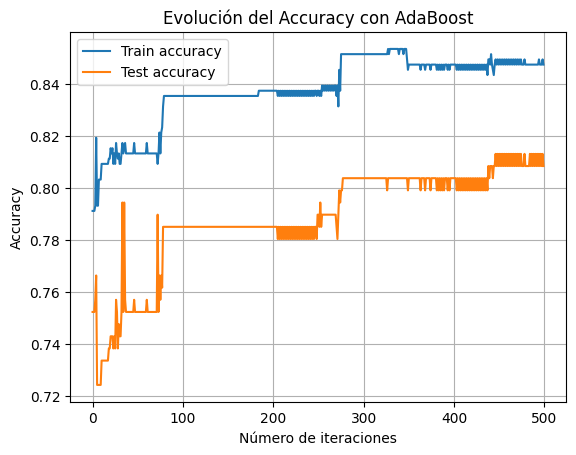

In [22]:
train_acc = []
test_acc = []

for y_train_pred in ada.staged_predict(X_train):
    train_acc.append(accuracy_score(y_train, y_train_pred))

for y_test_pred in ada.staged_predict(X_test):
    test_acc.append(accuracy_score(y_test, y_test_pred))

import matplotlib.pyplot as plt

plt.plot(train_acc, label='Train accuracy')
plt.plot(test_acc, label='Test accuracy')
plt.xlabel('Número de iteraciones')
plt.ylabel('Accuracy')
plt.title('Evolución del Accuracy con AdaBoost')
plt.legend()
plt.grid()
plt.show()

Nuevamente, decidamos sobre nuestro ensamble buscar hiperparámetros óptimos, como hicimos con RandomForest. Para Adaboost, mencionamos los siguientes como hiperparámetros a optimizar:

- **n_estimators**: cantidad de weak learners que se combinan. Un valor bajo puede subajustar (tenemos una serie de modelos corta) , y uno muy alto puede sobreajustar.

- **learning_rate**: controla cuánto contribuye cada weak learner en la predicción final. Disminuir este valor puede ayudar a generalizar mejor, pero deben combinarse ambos (learning_rate y n_estimators) de manera acorde

En este caso también sumamos el max_depth del estimador usados (árboles de profundidad 1 o 2)

In [23]:

param_grid = {
    'n_estimators': [10, 50, 100,500,1000],
    'learning_rate': [0.01, 0.1,0.5, 1],
    'estimator__max_depth': [1, 2]
}

base = DecisionTreeClassifier(random_state=42)
ada = AdaBoostClassifier(estimator=base, random_state=42)

grid_search = GridSearchCV(ada, param_grid, cv=5, scoring='accuracy', n_jobs=1,verbose=3)
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor accuracy en validación cruzada:", grid_search.best_score_)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV 1/5] END estimator__max_depth=1, learning_rate=0.01, n_estimators=10;, score=0.740 total time=   0.0s
[CV 2/5] END estimator__max_depth=1, learning_rate=0.01, n_estimators=10;, score=0.810 total time=   0.0s
[CV 3/5] END estimator__max_depth=1, learning_rate=0.01, n_estimators=10;, score=0.840 total time=   0.0s
[CV 4/5] END estimator__max_depth=1, learning_rate=0.01, n_estimators=10;, score=0.768 total time=   0.0s
[CV 5/5] END estimator__max_depth=1, learning_rate=0.01, n_estimators=10;, score=0.798 total time=   0.0s
[CV 1/5] END estimator__max_depth=1, learning_rate=0.01, n_estimators=50;, score=0.740 total time=   0.1s
[CV 2/5] END estimator__max_depth=1, learning_rate=0.01, n_estimators=50;, score=0.810 total time=   0.1s
[CV 3/5] END estimator__max_depth=1, learning_rate=0.01, n_estimators=50;, score=0.840 total time=   0.1s
[CV 4/5] END estimator__max_depth=1, learning_rate=0.01, n_estimators=50;, score=0.768 tot

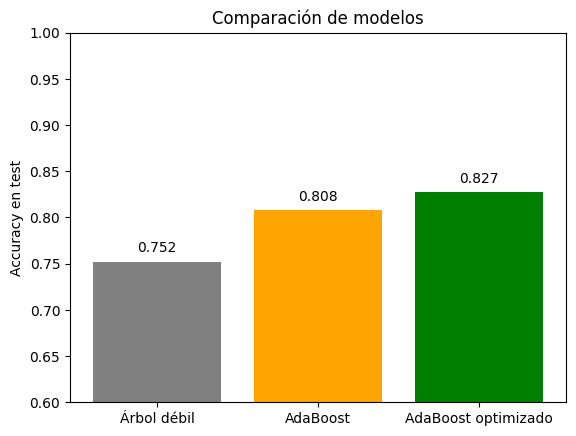

In [24]:
# Weak Learnerr
base_weak = DecisionTreeClassifier(max_depth=1, random_state=42)
base_weak.fit(X_train, y_train)
acc_base = accuracy_score(y_test, base_weak.predict(X_test))

# AdaBoost con mismos hiperparámetros que antes
ada_default = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=500,learning_rate=1.0, random_state=42)
ada_default.fit(X_train, y_train)
acc_ada = accuracy_score(y_test, ada_default.predict(X_test))

# AdaBoost con mejores hiperparámetros encontrados
best_ada = grid_search.best_estimator_
acc_best_ada = accuracy_score(y_test, best_ada.predict(X_test))

# Comparación en gráfico de barras
modelos = ['Árbol débil', 'AdaBoost', 'AdaBoost optimizado']
accuracies = [acc_base, acc_ada, acc_best_ada]

plt.bar(modelos, accuracies, color=['gray', 'orange', 'green'])
plt.ylabel('Accuracy en test')
plt.ylim(0.6, 1.0)
plt.title('Comparación de modelos')
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f'{acc:.3f}', ha='center')
plt.show()
